<a href="https://colab.research.google.com/github/enriquefroes/futebol-dinheiro-e-desempenho/blob/main/notebooks/03_bets_x_gastos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_futebol'
except ImportError:
    BASE = './analise_futebol'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (DADOS, GRAF, TAB):
    os.makedirs(p, exist_ok=True)

ARQUIVO = os.path.join(DADOS, 'clubes_2026.csv')
if not os.path.exists(ARQUIVO):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb para criar o CSV no Drive.')
df = pd.read_csv(ARQUIVO)

MESES_DECORRIDOS = 9
df['pontos_por_jogo'] = df['pontos'] / df['jogos']
df['gasto_transferencias'] = df['gasto_janela1'].fillna(0) + df['gasto_janela2'].fillna(0)
df['folha_anual'] = df['folha_mensal'] * 13
df['folha_ate_agora'] = df['folha_mensal'] * MESES_DECORRIDOS

def rotular(ax, dados, x, y, ajustes=None):
    """Escreve o nome do clube ao lado de cada ponto; 'ajustes' desloca rótulos sobrepostos."""
    ajustes = ajustes or {}
    for _, r in dados.iterrows():
        ax.annotate(r['time'], (r[x], r[y]), xytext=ajustes.get(r['time'], (6, 4)),
                    textcoords='offset points', fontsize=9)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150)
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
d = df.dropna(subset=['patrocinio_bet_anual']).copy()
d['gasto_total_anual'] = d['folha_anual'] + d['gasto_transferencias']
d['cobertura_folha_%'] = d['patrocinio_bet_anual'] / d['folha_anual'] * 100
d['cobertura_gasto_total_%'] = d['patrocinio_bet_anual'] / d['gasto_total_anual'] * 100
d['patrocinio_por_milhao_gasto'] = d['patrocinio_bet_anual'] / d['gasto_total_anual']

tabela = (d[['time', 'patrocinador_bet', 'patrocinio_bet_anual', 'folha_anual', 'gasto_transferencias',
             'gasto_total_anual', 'cobertura_folha_%', 'cobertura_gasto_total_%', 'fonte_patrocinio']]
          .sort_values('cobertura_folha_%', ascending=False).round(1))
tabela.to_csv(os.path.join(TAB, '03_bets_x_gastos.csv'), index=False)
sem = df[df['patrocinador_bet'] == 'sem bet']['time'].tolist()
print('Sem patrocínio de bet (não entram):', ', '.join(sem))
print('Bet sem valor informado:', ', '.join(df[df['patrocinador_bet'] == 'não identificado']['time']))
tabela

Sem patrocínio de bet (não entram): Athletico-PR, Bahia, Coritiba, Bragantino, Mirassol, Internacional
Bet sem valor informado: Grêmio


,time,patrocinador_bet,patrocinio_bet_anual,folha_anual,gasto_transferencias,gasto_total_anual,cobertura_folha_%,cobertura_gasto_total_%,fonte_patrocinio
19,Chapecoense,Zeroum Bet,15.0,29.2,4.2,33.4,51.3,44.8,Balancete 1º tri 2026 (R$ 3.75 mi x 4)
12,Vitória,7K,20.0,48.8,26.2,75.0,41.0,26.7,Lance! 26/09/2026
0,Flamengo,Betano,268.5,689.0,407.4,1096.4,39.0,24.5,Lance! 26/09/2026
18,Remo,Vaidebet,12.0,42.2,10.3,52.5,28.4,22.8,Lance! 26/09/2026
13,Corinthians,Esportes da Sorte,150.0,572.0,4.9,576.9,26.2,26.0,Lance! 26/09/2026
10,São Paulo,Superbet,95.0,403.0,47.3,450.3,23.6,21.1,Lance! 26/09/2026
1,Palmeiras,Sportingbet,100.0,585.0,212.2,797.2,17.1,12.5,Lance! 26/09/2026
11,Botafogo,VBet,55.0,338.0,73.2,411.2,16.3,13.4,Lance! 26/09/2026
6,Atlético-MG,H2Bet,60.0,377.0,165.8,542.8,15.9,11.1,Lance! 26/09/2026
15,Vasco,Sportingbet,25.0,214.5,228.6,443.1,11.7,5.6,Lance! 26/09/2026


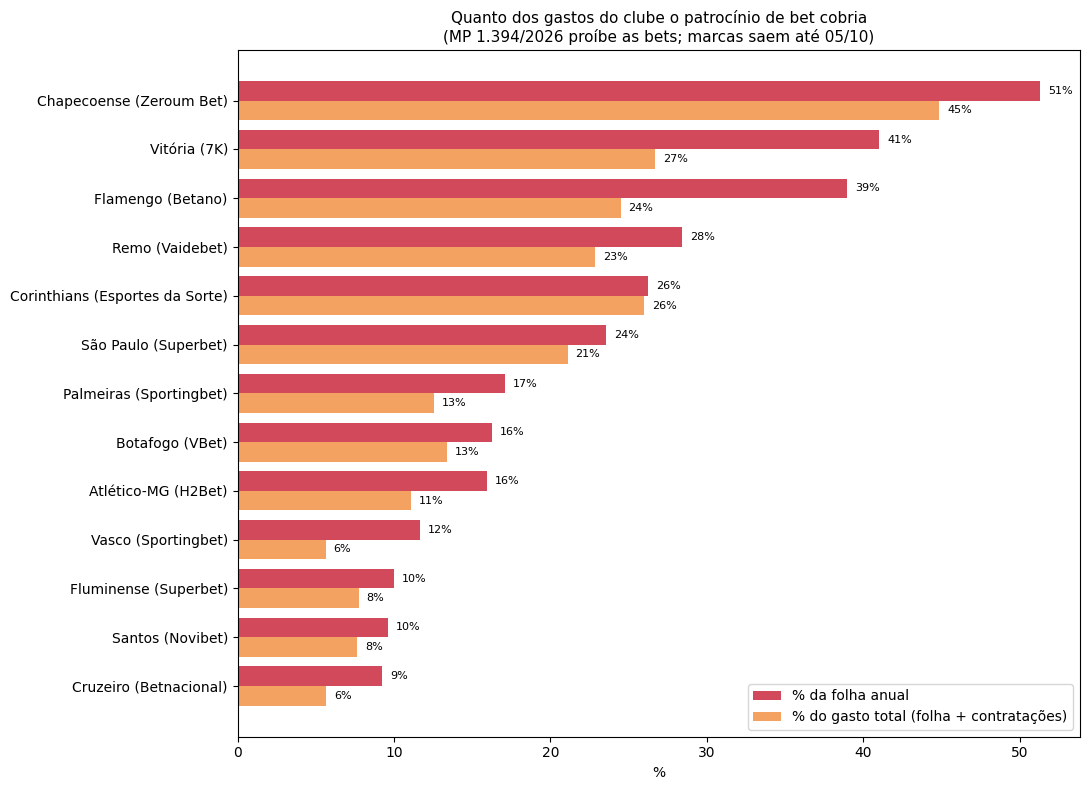

Salvo em /content/drive/MyDrive/analise_futebol/graficos/03a_cobertura_bets.png


In [3]:
t = d.sort_values('cobertura_folha_%')
y = np.arange(len(t))
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(y + 0.2, t['cobertura_folha_%'], height=0.4, color='#d1495b', label='% da folha anual')
ax.barh(y - 0.2, t['cobertura_gasto_total_%'], height=0.4, color='#f4a261', label='% do gasto total (folha + contratações)')
ax.set_yticks(y)
ax.set_yticklabels(t['time'] + ' (' + t['patrocinador_bet'] + ')')
for i, (a, b) in enumerate(zip(t['cobertura_folha_%'], t['cobertura_gasto_total_%'])):
    ax.text(a + 0.5, i + 0.2, f'{a:.0f}%', va='center', fontsize=8)
    ax.text(b + 0.5, i - 0.2, f'{b:.0f}%', va='center', fontsize=8)
ax.set_title('Quanto dos gastos do clube o patrocínio de bet cobria\n(MP 1.394/2026 proíbe as bets; marcas saem até 05/10)', fontsize=11)
ax.set_xlabel('%')
ax.legend(loc='lower right')
salvar('03a_cobertura_bets.png')

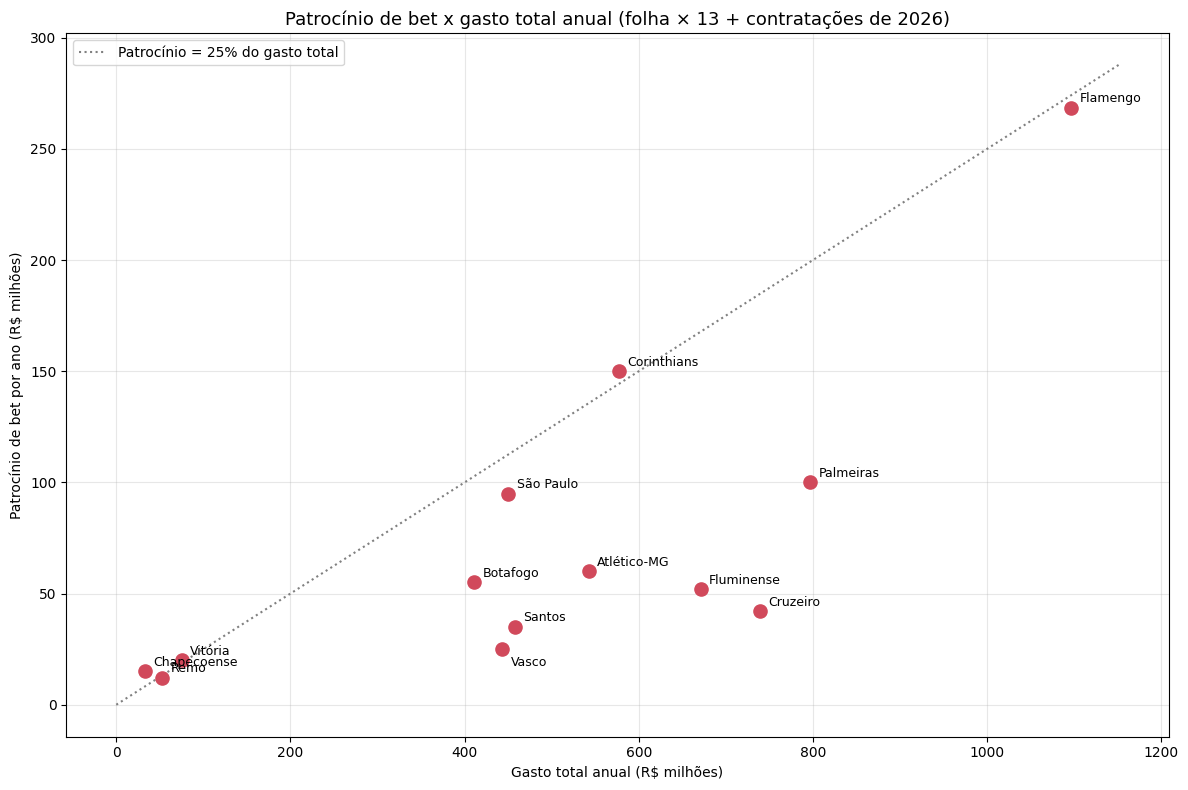

Salvo em /content/drive/MyDrive/analise_futebol/graficos/03b_patrocinio_x_gasto_total.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(d['gasto_total_anual'], d['patrocinio_bet_anual'], s=90, color='#d1495b', zorder=3)
xs = np.linspace(0, d['gasto_total_anual'].max() * 1.05, 100)
ax.plot(xs, xs * 0.25, ':', color='gray', label='Patrocínio = 25% do gasto total')
rotular(ax, d, 'gasto_total_anual', 'patrocinio_bet_anual', {'Vasco': (6, -12)})
ax.set_title('Patrocínio de bet x gasto total anual (folha × 13 + contratações de 2026)', fontsize=13)
ax.set_xlabel('Gasto total anual (R$ milhões)')
ax.set_ylabel('Patrocínio de bet por ano (R$ milhões)')
ax.grid(alpha=0.3); ax.legend(loc='upper left')
salvar('03b_patrocinio_x_gasto_total.png')